In [1]:
import pandas as pd
import numpy as np
import ast
import re

## 0. LOAD DATA

In [2]:
df = pd.read_csv("heart_diagnoses_1.csv")

# 1. Removing Duplicates & corrupt values 
### by comparing [subject_id + subject_id_dx]

In [3]:
df[df['subject_id'] != df['subject_id_dx']]

,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,HPI,physical_exam,chief_complaint,...,ECG,MRI,reports,subject_id_dx,icd_code,long_title,gender,age,anchor_year,dod
4761,19279625-DS-15,19998498,29045048,DS,15,2181-12-06 03:00:00,2181-12-09 13:03:00,:\nPatient is a ___ male with a PMH of CAD s/p...,ADMISSION PHYSICAL EXAMINATION: \n===========...,\nChest Pain\n \n,...,[],[],Sinus rhythm with PAC(s) with 1st degree A-V b...,19279625,I21,Acute myocardial infarction,NaN,NaN,NaN,NaN
4762,17196497-DS-3,19998499,29464876,DS,3,2159-03-06 03:00:00,2159-03-07 23:01:00,":\n___ yo M with hx of CAD s/p MI, ___ (LVEF 3...",Admission exam:\n \nVS: 98.5 110-140/60-70 ___...,\nShortness of breath\n \n,...,[],[],Ventricular pacing | Pacemaker rhythm - no fur...,17196497,I25,Chronic ischemic heart disease,NaN,NaN,NaN,NaN
4763,17881570-DS-5,19998500,26323690,DS,5,2158-04-25 03:00:00,2158-04-26 21:36:00,":\n___ with PMH recently diagnosed a-fib, HTN,...",ADMISSION PHYSICAL EXAM:\n====================...,\nFast Heart Rate\n \n,...,"[': Atrial flutter, 141 bpm \nPost-DCCV', ': ...",[],Atrial flutter with rapid ventricular response...,17881570,I48,Atrial fibrillation and flutter,NaN,NaN,NaN,NaN
4764,11250426-DS-4,19998501,25298090,DS,4,2193-09-28 03:00:00,2193-10-02 00:54:00,:\n___ male with history of COPD not on home O...,Admission:\nVitals: 98.4 PO 156/76 L Lying 73...,"\nDyspnea, Cough \n \n",...,[],[],Atrial-sensed ventricular-paced rhythm | Ventr...,11250426,I50,Heart failure,NaN,NaN,NaN,NaN
4765,18107138-DS-8,19998502,28751589,DS,8,2159-06-15 03:00:00,2159-06-17 03:38:00,":\n___ HTN, HLD, recent d/c ___ following emer...",Examined pre-cath at 14:45\nVS: T=pending BP=1...,\nChest pain\n \n,...,['Date of ___ 5:09:50 ___\n\nSinus bradycardi...,[],--- Warning: Data quality may affect interpret...,18107138,I21,Acute myocardial infarction,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4859,13690559-DS-19,19998596,24860241,DS,19,2180-01-24 03:00:00,2180-01-24 20:12:00,:\nMs ___ is a ___ year old woman with carotid...,ADMISSION EXAM\n=====================\nVITALS:...,\nRight shoulder pain\n \n,...,['___:\nAtrial flutter with 4:1 conduction and...,[],Possible atrial flutter with rapid ventricular...,13690559,I48,Atrial fibrillation and flutter,NaN,NaN,NaN,NaN
4860,14997789-DS-12,19998597,23720781,DS,12,2131-10-11 03:00:00,2131-10-11 16:17:00,:\nMs. ___ is a ___ woman with renal cell carc...,Physical Exam:\nVS: T: T 95.7 bp 102/60 HR 1...,\nDyspnea\n \n,...,[],[],Sinus tachycardia. | Possible anterior infarct...,14997789,I31,Other diseases of pericardium,NaN,NaN,NaN,NaN
4861,10754991-DS-13,19998598,26940500,DS,13,2135-04-03 03:00:00,2135-04-05 00:12:00,":\n___ T2DM, fibromyalgia, GERD, hypothyroidis...",=================\nADMISSION EXAM:\n==========...,\nPalpitations\n \n,...,['(___): Narrow complex tachycardia. Supravent...,[],Supraventricular tachycardia | Sinus rhythm | ...,10754991,I47,Paroxysmal tachycardia,NaN,NaN,NaN,NaN
4862,17922874-DS-8,19998599,20343031,DS,8,2158-05-23 03:00:00,2158-05-23 20:55:00,":\n___ with H/O of type 2 diabetes mellitus, h...","General: Middle aged Caucasian man in NAD, com...","\nAbdominal pain, nausea, vomiting, and diarrh...",...,['Study Date of ___ 7:51:52 ___\nSinus rhythm ...,[],*** CONSIDER ACUTE ST ELEVATION MI *** | Sinus...,17922874,I30,Acute pericarditis,NaN,NaN,NaN,NaN


In [4]:
df[df['subject_id'] != df['subject_id_dx']][['subject_id','subject_id_dx','hadm_id']].drop_duplicates()

,subject_id,subject_id_dx,hadm_id
4761,19998498,19279625,29045048
4762,19998499,17196497,29464876
4763,19998500,17881570,26323690
4764,19998501,11250426,25298090
4765,19998502,18107138,28751589
...,...,...,...
4859,19998596,13690559,24860241
4860,19998597,14997789,23720781
4861,19998598,10754991,26940500
4862,19998599,17922874,20343031


In [5]:
df = df[df['subject_id'] == df['subject_id_dx']]

In [6]:
df[df['subject_id'] != df['subject_id_dx']]

,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,HPI,physical_exam,chief_complaint,...,ECG,MRI,reports,subject_id_dx,icd_code,long_title,gender,age,anchor_year,dod


In [7]:
# Drop exact duplicate rows
exact_duplicates = df[df.duplicated(keep=False)]
print("Exact duplicate rows that will be dropped:")
print(exact_duplicates)

# Drop them
df = df.drop_duplicates()

# Drop duplicates based on note_id
noteid_duplicates = df[df.duplicated(subset=['note_id'], keep=False)]
print("\nRows with duplicated note_id that will be dropped (keeping first):")
print(noteid_duplicates)

# Drop duplicates based on note_id, keep first occurrence
df.drop_duplicates(subset=['note_id'], keep='first', inplace=True)

# Optional: reset index
df.reset_index(drop=True, inplace=True)

Exact duplicate rows that will be dropped:
Empty DataFrame
Columns: [note_id, subject_id, hadm_id, note_type, note_seq, charttime, storetime, HPI, physical_exam, chief_complaint, invasions, X-ray, CT, Ultrasound, CATH, ECG, MRI, reports, subject_id_dx, icd_code, long_title, gender, age, anchor_year, dod]
Index: []

[0 rows x 25 columns]

Rows with duplicated note_id that will be dropped (keeping first):
Empty DataFrame
Columns: [note_id, subject_id, hadm_id, note_type, note_seq, charttime, storetime, HPI, physical_exam, chief_complaint, invasions, X-ray, CT, Ultrasound, CATH, ECG, MRI, reports, subject_id_dx, icd_code, long_title, gender, age, anchor_year, dod]
Index: []

[0 rows x 25 columns]


## 2. BASIC CLEANING: Strip whitespace, unify empty values

In [8]:
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
df.replace(['', ' ', 'NA', 'N/A'], np.nan, inplace=True)

## 3. CLEAN DATETIME COLUMNS

In [9]:
for col in ['charttime', 'storetime']:
    df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

# Optional sanity check, compute store lag (hours)
df["store_lag_hours"] = (df["storetime"] - df["charttime"]).dt.total_seconds() / 3600

In [10]:
df["chief_complaint"]

0                Shortness of breath
1                            dyspnea
2                         chest pain
3                     chest pressure
4       Abnormal Stress Test, New AI
                    ...             
4756                Dyspnea, Fatigue
4757    Transfered for EP evaluation
4758                            VFib
4759                      chest pain
4760                      Chest pain
Name: chief_complaint, Length: 4761, dtype: object

#### Checking how the data is looking

In [11]:
# Combine all columns to check
columns_to_check = [
    'HPI', 'physical_exam', 'chief_complaint', 'invasions', 
    'X-ray', 'CT', 'Ultrasound', 'CATH', 'ECG', 'MRI',
    'reports', 'icd_code', 'long_title',
    'gender', 'age', 'anchor_year', 'dod'
]
print("Total Rows: ", df.shape)
print("Number of empty/missing rows per column:\n")
for col in columns_to_check:
    # Count NaNs
    na_count = df[col].isna().sum()
    # Count empty strings
    empty_count = (df[col] == '').sum()
    # Count empty lists
    empty_list_count = df[col].apply(lambda x: isinstance(x, list) and len(x) == 0).sum()
    # Total “empty” if you want
    total_empty = na_count + empty_count + empty_list_count
    
    print(f"{col:<15} : NaN={na_count:>5}, Empty String={empty_count:>5}, Empty List={empty_list_count:>5}, Total={total_empty:>5}")

Total Rows:  (4761, 26)
Number of empty/missing rows per column:

HPI             : NaN=    0, Empty String=    0, Empty List=    0, Total=    0
physical_exam   : NaN=    0, Empty String=    0, Empty List=    0, Total=    0
chief_complaint : NaN=   12, Empty String=    0, Empty List=    0, Total=   12
invasions       : NaN=   24, Empty String=    0, Empty List=    0, Total=   24
X-ray           : NaN=    0, Empty String=    0, Empty List=    0, Total=    0
CT              : NaN=    0, Empty String=    0, Empty List=    0, Total=    0
Ultrasound      : NaN=    0, Empty String=    0, Empty List=    0, Total=    0
CATH            : NaN=    0, Empty String=    0, Empty List=    0, Total=    0
ECG             : NaN=    0, Empty String=    0, Empty List=    0, Total=    0
MRI             : NaN=    0, Empty String=    0, Empty List=    0, Total=    0
reports         : NaN=    0, Empty String=    0, Empty List=    0, Total=    0
icd_code        : NaN=    0, Empty String=    0, Empty List=    0

## 4. Drop Columns (note_type, note_seq, subject_id_dx, anchor_year)

In [12]:
df = df.drop(["note_type", "note_seq", "subject_id_dx", "anchor_year", "note_id"], axis=1)

In [13]:
df

,subject_id,hadm_id,charttime,storetime,HPI,physical_exam,chief_complaint,invasions,X-ray,CT,...,CATH,ECG,MRI,reports,icd_code,long_title,gender,age,dod,store_lag_hours
0,10000980,29654838,2188-06-01 03:00:00,2188-07-01 23:49:00,":\n___ yo woman with h/o hypertension, hyperli...","Admission exam:\nGENERAL- Oriented x3. Mood, a...",Shortness of breath,None,"['___:', 'views of the chest demonstrate low l...",[],...,[],['___ 7:56:06 ___ \nBaseline artifact. Sinus...,[],Sinus bradycardia with sinus arrhythmia | Prol...,I50,Heart failure,F,75.0,2193-08-26,740.816667
1,10000980,26913865,2189-04-07 03:00:00,2189-04-07 22:50:00,":\nThis is a ___ M with history of diabetes, d...",ADMISSION EXAM:\nGeneral- appears comfortable...,dyspnea,Cardiac catheterization ___,[': ___\nRight upper lobe pneumonia or mass. ...,['CHEST: ___\n1. Diffuse confluent ground-gla...,...,[': ___\n1. Selective coronary angiography of ...,[],[],Sinus bradycardia with sinus arrhythmia | Prol...,I21,Acute myocardial infarction,F,75.0,2193-08-26,19.833333
2,10002013,24760295,NaT,NaT,":\n___ w/ PMH of CAD s/p PCI x3, s/p off-pump ...",Admission:\nVS- T 99.4 BP 157/88 HR 118 RR 24 ...,chest pain,cardiac catheterization,['___- New moderate left pleural effusion with...,['Chest ___. No CT evidence for pulmonary emb...,...,['___. Selective coronary angiography of this ...,['on admission- Sinus tachycardia. Extensive S...,[],Sinus tachycardia | Extensive ST-T changes may...,I21,Acute myocardial infarction,NaN,NaN,NaN,NaN
3,10002155,23822395,NaT,NaT,:\n___ is a ___ yo female with a past medical ...,"GENERAL: WDWN in NAD. Oriented x3. Mood, affec...",chest pressure,Cardiac cathetherization,[],"['anteriorly, no \ncrackles, wheezes or rhonch...",...,[': \nLMCA: 40% distal\nLAD: Occluded difficu...,[': new LBBB with STE in V1 -V3 & V5 that in ...,[],*** CONSIDER ACUTE ST ELEVATION MI *** | Sinus...,I21,Acute myocardial infarction,NaN,NaN,NaN,NaN
4,10004457,28723315,NaT,NaT,:\nMr. ___ is a ___ with a hx of CAD (s/p DES ...,On Admission:\nVS- 97.8 157/64 101 18 98% RA \...,"Abnormal Stress Test, New AI",None,[],['/MR or TEE is suggested to \nevaluate for po...,...,[],['(see exercise report for details). Resting s...,[],Sinus rhythm | Normal ECG,I35,Nonrheumatic aortic valve disorders,M,66.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4756,19993951,29858732,NaT,NaT,:\nMr. ___ is a ___ yo male with PMH significa...,"ON ADMISSION:\nT 97.7F, BP: 91/63, HR: 80, RR ...","Dyspnea, Fatigue",None,['___:\n\nIMPRESSION: \nComparison to ___. N...,[],...,[],['(___):\nProbable underlying atrial fibrillat...,[],Atrial fibrillation with slow ventricular resp...,I50,Heart failure,M,72.0,2142-03-19,NaN
4757,19994505,22534556,2183-04-05 03:00:00,2183-05-05 19:51:00,":\n___ yo M PMHx DM, HTN, hypercholesterolemia...",ADMISSION EXAM:\nVS: 97.5 138/74 89 20 95%RA ...,Transfered for EP evaluation,Cardiac catheterization ___ \nDual chamber ___...,['Study Date of ___ 4:19 AM \nIMPRESSION: Prob...,[],...,['Study Date of ___ \n\nCOMMENTS: \n1. Se...,['Study Date of ___ 8:28:28 AM \nDemand pacin...,[],Atrial fibrillation with frequent multifocal P...,I44,Atrioventricular and left bundle-branch block,NaN,NaN,NaN,736.850000
4758,19997293,28847872,2124-11-01 03:00:00,2124-11-01 22:21:00,:\n___ yo M w/ h/o paraplegia ___ T9 epidural ...,"ADMISSION:\nGENERAL: overweight, intubated. Pa...",VFib,surgical debridement of wound\nPlacement of ex...,[': The ET tube is 6 cm above the carina. Th...,[],...,[],['___:\nIndeterminate atrial rhythm. Ventricul...,[],Possible idioventricular rhythm with slow vent...,I44,Atrioventricular and left bundle-branch block,NaN,NaN,NaN,19.350000
4759,19997367,24169669,NaT,2128-10-03 02:19:00,:\n___ is a ___ year old woman with multiple m...,ADMISSION PHYSICAL EXAM \n====================...,chest pain,-Cardiac catheterization via right groin acces...,[],[],...,[':\n1. Low filling pressures after diuresis f...,[':\nSinus rhythm with at

In [14]:
# Find all duplicated hadm_id values
duplicated_hadm = df[df.duplicated(subset='hadm_id', keep=False)]

# View all rows with duplicated hadm_id
print(duplicated_hadm)


Empty DataFrame
Columns: [subject_id, hadm_id, charttime, storetime, HPI, physical_exam, chief_complaint, invasions, X-ray, CT, Ultrasound, CATH, ECG, MRI, reports, icd_code, long_title, gender, age, dod, store_lag_hours]
Index: []

[0 rows x 21 columns]


## 5. CLEAN IDENTIFIERS (Make numeric where possible)

In [15]:
df["subject_id"] = pd.to_numeric(df["subject_id"], errors="coerce")
df["hadm_id"] = pd.to_numeric(df["hadm_id"], errors="coerce")

## 6. STANDARDIZE GENDER

In [16]:
df["gender"] = df["gender"].str.upper().replace({
    "FEMALE": "F",
    "MALE": "M"
})

## 7. CLEAN ICD CODES

In [17]:
df["icd_code"] = df["icd_code"].str.upper().str.strip()

# Remove invalid characters
df["icd_code"] = df["icd_code"].apply(lambda x: re.sub(r"[^A-Z0-9.]", "", x) if isinstance(x, str) else x)

## 8. HANDLE AGE (fix outliers)

In [18]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# Remove impossible ages (not >120)
df.loc[df["age"] > 120, "age"] = np.nan

## 9. FINAL CLEAN MATRIX

In [19]:
# See missing values per column:
missing_info = df.isna().mean().sort_values(ascending=False)

print("Missing Value Summary:")
print(missing_info)

# Save cleaned dataset
df.to_csv("heart_diagnoses_clean.csv", index=False)

Missing Value Summary:
dod                0.916404
age                0.713716
gender             0.713716
store_lag_hours    0.663096
storetime          0.606805
charttime          0.604915
invasions          0.005041
chief_complaint    0.002520
MRI                0.000000
long_title         0.000000
icd_code           0.000000
reports            0.000000
subject_id         0.000000
ECG                0.000000
CATH               0.000000
hadm_id            0.000000
CT                 0.000000
X-ray              0.000000
physical_exam      0.000000
HPI                0.000000
Ultrasound         0.000000
dtype: float64


In [20]:
counts = df['icd_code'].value_counts()

df[['icd_code', 'long_title']].drop_duplicates().assign(count=lambda x: x['icd_code'].map(counts)).sort_values('icd_code')

,icd_code,long_title,count
195,I20,Angina pectoris,35
1,I21,Acute myocardial infarction,1398
824,I22,Subsequent ST elevation (STEMI) and non-ST ele...,5
376,I24,Other acute ischemic heart diseases,11
6,I25,Chronic ischemic heart disease,633
116,I30,Acute pericarditis,81
31,I31,Other diseases of pericardium,146
42,I33,Acute and subacute endocarditis,36
524,I34,Nonrheumatic mitral valve disorders,49
4,I35,Nonrheumatic aortic valve disorders,229


## 10. Feature extraction

In [21]:
"""
Unified Cardiac Feature Extraction Pipeline. Combines all feature extraction methods and creates two datasets:
1. Complete dataset with all extracted features
2. Core dataset with selected key features
"""

import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

class UnifiedCardiacFeatureExtractor:
    """Master class to extract and organize all cardiac features"""
    
    def __init__(self):
        """Initialize all extractors"""
        self.severity_map = {
            'trace': 1, 'trivial': 1, 'mild': 2, 'moderate': 3,
            'moderately': 3, 'severe': 4, 'mod-severe': 3.5,
            'moderate to severe': 3.5, 'mod to severe': 3.5
        }
        self.valve_grades = {'1+': 1, '2+': 2, '3+': 3, '4+': 4}
        
        # Define core feature set (30 most important features)
        self.core_features = [
            # Demographics & Basic Info (5)
            'subject_id', 'hadm_id', 'age', 'gender', 'icd_code',
            
            # Vital Signs (6)
            'temperature', 'bp_systolic', 'bp_diastolic', 
            'heart_rate', 'respiratory_rate', 'oxygen_saturation',
            
            # Cardiac Function (5)
            'lvef', 'lvef_category', 'lv_dilated', 
            'mitral_regurgitation', 'aortic_stenosis',
            
            # Disease Etiology (4)
            'coronary_artery_disease', 'num_vessels_diseased',
            'atrial_fibrillation', 'severe_stenosis',
            
            # Severity Markers (5)
            'pulmonary_hypertension', 'wall_motion_abnormality',
            'low_cardiac_output', 'st_elevation', 'lbbb',
            
            # Complications (3)
            'pleural_effusion', 'pulmonary_edema', 'pericardial_effusion',
            
            # Composite Scores (2)
            'heart_failure_severity_score', 'risk_category'
        ]
    
    # ==================== PHYSICAL EXAM EXTRACTION ====================
    
    def extract_physical_exam_features(self, text):
        """Extract features from physical examination text"""
        if not isinstance(text, str):
            return {}
        
        text = str(text).upper()
        features = {}
        
        # Vital Signs
        temp_match = re.search(r'T[=:\s]*(\d{2,3}\.?\d?)', text)
        if temp_match:
            features['temperature'] = float(temp_match.group(1))
        
        bp_match = re.search(r'BP[=:\s]*(\d{2,3})/(\d{2,3})', text)
        if bp_match:
            features['bp_systolic'] = int(bp_match.group(1))
            features['bp_diastolic'] = int(bp_match.group(2))
        
        hr_match = re.search(r'HR[=:\s]*(\d{2,3})', text)
        if hr_match:
            features['heart_rate'] = int(hr_match.group(1))
        
        rr_match = re.search(r'RR[=:\s]*(\d{1,2})', text)
        if rr_match:
            features['respiratory_rate'] = int(rr_match.group(1))
        
        o2_match = re.search(r'O2\s*SAT[=:\s]*(\d{2,3})%?', text)
        if not o2_match:
            o2_match = re.search(r'(\d{2,3})%?\s*(?:ON\s*)?(?:RA|[0-9]L)', text)
        if o2_match:
            features['oxygen_saturation'] = int(o2_match.group(1))
        
        # Clinical abbreviations
        features['perrl'] = 1 if 'PERRL' in text or 'PERRLA' in text else 0
        features['nad'] = 1 if 'NAD' in text else 0
        features['rrr_cardiac'] = 1 if 'RRR' in text else 0
        features['ctab'] = 1 if 'CTAB' in text else 0
        
        # Edema
        no_edema = bool(re.search(r'NO\s+(?:C/C/)?EDEMA', text))
        has_edema = bool(re.search(r'\d\+.*EDEMA|EDEMA.*\d\+', text))
        features['edema_present'] = 0 if no_edema else (1 if has_edema else np.nan)
        
        # Lung sounds
        features['wheezes_present'] = 1 if re.search(r'WHEEZ', text) and not re.search(r'NO\s+WHEEZ', text) else 0
        has_crackles = bool(re.search(r'CRACKLE|RALE', text))
        no_crackles = bool(re.search(r'NO\s+(?:CRACKLE|RALE)', text))
        features['crackles_present'] = 1 if has_crackles and not no_crackles else 0
        
        # Cardiac sounds
        has_murmur = bool(re.search(r'MURMUR', text))
        no_murmur = bool(re.search(r'NO\s+MURMUR', text))
        features['murmur_present'] = 1 if has_murmur and not no_murmur else 0
        
        return features
    
    # ==================== ULTRASOUND/ECHO EXTRACTION ====================
    
    def parse_report_list(self, report_data):
        """Parse nested list structure from reports"""
        if pd.isna(report_data) or report_data == '[]':
            return []
        if isinstance(report_data, str):
            report_data = report_data.strip('[]')
            texts = re.findall(r"'([^']*)'", report_data)
            return [t for t in texts if t.strip() and t != '___']
        return []
    
    def extract_ultrasound_features(self, reports):
        """Extract echocardiogram features"""
        features = {}
        full_text = ' '.join(reports).upper() if reports else ''
        
        if not full_text.strip():
            return features
        
        # LVEF
        lvef_patterns = [
            r'LVEF[=:\s]*(\d{1,2})%?',
            r'EJECTION FRACTION[=:\s]*(\d{1,2})%?',
            r'EF[=:\s]*(\d{1,2})%?'
        ]
        
        for pattern in lvef_patterns:
            match = re.search(pattern, full_text)
            if match:
                ef_value = int(match.group(1))
                if 10 <= ef_value <= 80:
                    features['lvef'] = ef_value
                    if ef_value >= 50:
                        features['lvef_category'] = 'normal'
                    elif ef_value >= 40:
                        features['lvef_category'] = 'mildly_reduced'
                    elif ef_value >= 30:
                        features['lvef_category'] = 'moderately_reduced'
                    else:
                        features['lvef_category'] = 'severely_reduced'
                    break
        
        # LV size
        if re.search(r'LV.*DILAT|LEFT VENTRICULAR.*DILAT', full_text):
            features['lv_dilated'] = 1
        elif re.search(r'NORMAL.*LV.*SIZE', full_text):
            features['lv_dilated'] = 0
        
        # Wall motion abnormalities
        features['wall_motion_abnormality'] = 1 if re.search(r'HYPOKIN|AKINESIS|DYSKINESIS', full_text) else 0
        
        # Valve disease
        mr_match = re.search(r'MITRAL REGURGITATION.*?(\d\+|TRACE|MILD|MODERATE|SEVERE)', full_text)
        if mr_match:
            severity = mr_match.group(1).lower()
            if severity in self.valve_grades:
                features['mitral_regurgitation'] = self.valve_grades[severity]
            elif severity in self.severity_map:
                features['mitral_regurgitation'] = self.severity_map[severity]
        
        features['aortic_stenosis'] = 1 if re.search(r'AORTIC STENOSIS', full_text) and not re.search(r'NO.*AORTIC STENOSIS', full_text) else 0
        
        # Pulmonary hypertension
        features['pulmonary_hypertension'] = 1 if re.search(r'PULMONARY.*HYPERTENSION', full_text) else 0
        
        # Pericardial effusion
        features['pericardial_effusion'] = 1 if re.search(r'PERICARDIAL EFFUSION', full_text) and not re.search(r'NO PERICARDIAL', full_text) else 0
        
        # RV dysfunction
        features['rv_dysfunction'] = 1 if re.search(r'RV.*DYSFUNC|RIGHT VENT.*DYSFUNC', full_text) else 0
        
        return features
    
    # ==================== CATH EXTRACTION ====================
    
    def extract_cath_features(self, reports):
        """Extract cardiac catheterization features"""
        features = {}
        full_text = ' '.join(reports).upper() if reports else ''
        
        if not full_text.strip():
            return features
        
        # CAD
        vessel_match = re.search(r'(\d)[\s-]*VESSEL.*DISEASE', full_text)
        if vessel_match:
            features['num_vessels_diseased'] = int(vessel_match.group(1))
            features['coronary_artery_disease'] = 1
        elif re.search(r'NO.*SIGNIFICANT.*CAD', full_text):
            features['coronary_artery_disease'] = 0
            features['num_vessels_diseased'] = 0
        
        # Stenosis
        lad_match = re.search(r'LAD.*?(\d{2,3})%', full_text)
        if lad_match:
            features['lad_stenosis'] = int(lad_match.group(1))
        
        rca_match = re.search(r'RCA.*?(\d{2,3})%', full_text)
        if rca_match:
            features['rca_stenosis'] = int(rca_match.group(1))
        
        # Severe stenosis
        stenosis_values = [features.get('lad_stenosis', 0), features.get('rca_stenosis', 0)]
        features['severe_stenosis'] = 1 if any(s >= 70 for s in stenosis_values) else 0
        
        # Interventions
        features['stent_placed'] = 1 if re.search(r'STENT|PCI', full_text) else 0
        features['cabg'] = 1 if re.search(r'CABG|BYPASS', full_text) else 0
        
        # Hemodynamics
        ci_match = re.search(r'CARDIAC INDEX.*?(\d+\.?\d*)', full_text)
        if ci_match:
            ci_value = float(ci_match.group(1))
            features['cardiac_index'] = ci_value
            features['low_cardiac_output'] = 1 if ci_value < 2.0 else 0
        
        pcwp_match = re.search(r'PCWP.*?(\d{1,2})', full_text)
        if pcwp_match:
            pcwp_value = int(pcwp_match.group(1))
            features['pcwp'] = pcwp_value
            features['elevated_filling_pressure'] = 1 if pcwp_value > 18 else 0
        
        return features
    
    # ==================== ECG EXTRACTION ====================
    
    def extract_ecg_features(self, reports):
        """Extract ECG features"""
        features = {}
        full_text = ' '.join(reports).upper() if reports else ''
        
        if not full_text.strip():
            return features
        
        # Rhythm
        if re.search(r'ATRIAL FIBRILLATION|A\.?\s*FIB', full_text):
            features['rhythm'] = 'atrial_fibrillation'
            features['atrial_fibrillation'] = 1
        elif re.search(r'SINUS', full_text):
            features['rhythm'] = 'sinus'
            features['atrial_fibrillation'] = 0
        else:
            features['atrial_fibrillation'] = 0
        
        # Conduction blocks
        features['lbbb'] = 1 if re.search(r'LBBB|LEFT BUNDLE.*BLOCK', full_text) else 0
        features['rbbb'] = 1 if re.search(r'RBBB|RIGHT BUNDLE.*BLOCK', full_text) else 0
        
        # Ischemia
        features['st_elevation'] = 1 if re.search(r'ST.*ELEVATION', full_text) and not re.search(r'NO.*ST.*ELEVATION', full_text) else 0
        features['st_depression'] = 1 if re.search(r'ST.*DEPRESSION', full_text) else 0
        features['q_waves'] = 1 if re.search(r'\bQ\s*WAVE', full_text) else 0
        
        # LVH
        features['lvh'] = 1 if re.search(r'LVH|LEFT VENTRICULAR HYPERTROPHY', full_text) else 0
        
        return features
    
    # ==================== CT EXTRACTION ====================
    
    def extract_ct_features(self, reports):
        """Extract CT scan features"""
        features = {}
        full_text = ' '.join(reports).upper() if reports else ''
        
        if not full_text.strip():
            return features
        
        # Pulmonary findings
        features['pulmonary_embolism'] = 1 if re.search(r'PULMONARY EMBOLI|PE\b', full_text) and not re.search(r'NO.*PE', full_text) else 0
        
        features['pleural_effusion'] = 1 if re.search(r'PLEURAL EFFUSION', full_text) else 0
        
        features['pulmonary_edema'] = 1 if re.search(r'PULMONARY EDEMA|PULMONARY CONGESTION', full_text) else 0
        
        # Cardiac findings
        features['coronary_calcification'] = 1 if re.search(r'CORONARY.*CALCIF', full_text) else 0
        features['aortic_aneurysm'] = 1 if re.search(r'AORTIC ANEURYSM', full_text) else 0
        features['aortic_dissection'] = 1 if re.search(r'AORTIC DISSECTION', full_text) and not re.search(r'NO.*DISSECTION', full_text) else 0
        
        return features
    
    # ==================== COMPOSITE SCORES ====================
    
    def calculate_composite_scores(self, features):
        """Calculate composite clinical scores"""
        
        # Heart Failure Severity Score (0-10)
        hf_score = 0
        
        # EF component (0-4 points)
        ef_map = {'normal': 0, 'mildly_reduced': 1, 'moderately_reduced': 2, 'severely_reduced': 4}
        hf_score += ef_map.get(features.get('lvef_category'), 0)
        
        # Volume overload (0-3 points)
        hf_score += features.get('pulmonary_edema', 0)
        hf_score += features.get('pleural_effusion', 0)
        hf_score += features.get('elevated_filling_pressure', 0)
        
        # Cardiac output (0-2 points)
        hf_score += features.get('low_cardiac_output', 0) * 2
        
        # RV dysfunction (0-1 point)
        hf_score += features.get('rv_dysfunction', 0)
        
        features['heart_failure_severity_score'] = hf_score
        
        # CAD Severity Score (0-6)
        cad_score = features.get('num_vessels_diseased', 0)
        cad_score += features.get('severe_stenosis', 0) * 2
        cad_score += features.get('q_waves', 0)
        features['cad_severity_score'] = cad_score
        
        # Risk Category
        total_risk = hf_score + cad_score
        if total_risk <= 5:
            features['risk_category'] = 'Low'
        elif total_risk <= 10:
            features['risk_category'] = 'Medium'
        else:
            features['risk_category'] = 'High'
        
        return features
    
    # ==================== MAIN EXTRACTION ====================
    
    def extract_all_features(self, row):
        """Extract all features from a single row"""
        features = {}
        
        # Demographics and basic info
        features['subject_id'] = row.get('subject_id')
        features['hadm_id'] = row.get('hadm_id')
        features['age'] = row.get('age')
        features['gender'] = row.get('gender')
        features['icd_code'] = row.get('icd_code')
        features['long_title'] = row.get('long_title')
        features['dod'] = row.get('dod')
        
        # Physical exam
        if 'physical_exam' in row:
            phys_features = self.extract_physical_exam_features(row['physical_exam'])
            features.update(phys_features)
        
        # Ultrasound
        if 'Ultrasound' in row:
            reports = self.parse_report_list(row['Ultrasound'])
            us_features = self.extract_ultrasound_features(reports)
            features.update(us_features)
        
        # CATH
        if 'CATH' in row:
            reports = self.parse_report_list(row['CATH'])
            cath_features = self.extract_cath_features(reports)
            features.update(cath_features)
        
        # ECG
        if 'ECG' in row:
            reports = self.parse_report_list(row['ECG'])
            ecg_features = self.extract_ecg_features(reports)
            features.update(ecg_features)
        
        # CT
        if 'CT' in row:
            reports = self.parse_report_list(row['CT'])
            ct_features = self.extract_ct_features(reports)
            features.update(ct_features)
        
        # Calculate composite scores
        features = self.calculate_composite_scores(features)
        
        return features
    
    def process_dataframe(self, df):
        """Process entire dataframe"""
        print(f"Processing {len(df)} records...")
        
        results = []
        for idx, row in df.iterrows():
            if idx % 100 == 0 and idx > 0:
                print(f"  Processed {idx}/{len(df)} records...")
            
            features = self.extract_all_features(row)
            results.append(features)
        
        result_df = pd.DataFrame(results)
        print(f"\nExtraction complete! Total features: {len(result_df.columns)}")
        
        return result_df
    
    def create_complete_dataset(self, original_df, features_df):
        """Merge original data with all extracted features"""
        # Keep all original columns + all extracted features
        complete_df = pd.concat([original_df, features_df], axis=1)
        
        # Remove duplicate columns
        complete_df = complete_df.loc[:, ~complete_df.columns.duplicated()]
        
        return complete_df
    
    def create_core_dataset(self, complete_df):
        """Create dataset with only core features"""
        # Select core features that exist in the dataframe
        available_core = [col for col in self.core_features if col in complete_df.columns]
        
        core_df = complete_df[available_core].copy()
        
        print(f"\nCore dataset created with {len(available_core)}/{len(self.core_features)} core features")
        
        return core_df
    
    def get_summary_statistics(self, features_df):
        """Generate summary statistics"""
        summary_data = []
        
        for col in features_df.columns:
            if col in ['subject_id', 'hadm_id', 'icd_code', 'long_title', 'dod', 'gender']:
                continue
            
            non_null = features_df[col].notna().sum()
            pct = (non_null / len(features_df)) * 100
            
            summary_data.append({
                'feature': col,
                'non_null_count': non_null,
                'pct_complete': round(pct, 1),
                'type': str(features_df[col].dtype)
            })
        
        return pd.DataFrame(summary_data).sort_values('pct_complete', ascending=False)


# ==================== USAGE ====================

# Initialize extractor
print("="*60)
print("UNIFIED CARDIAC FEATURE EXTRACTION PIPELINE")
print("="*60)

extractor = UnifiedCardiacFeatureExtractor()

# Extract features
features_df = extractor.process_dataframe(df)

# Create datasets
print("\n" + "="*60)
print("CREATING DATASETS")
print("="*60)

# Dataset 1: Complete (original + all extracted features)
df_complete = extractor.create_complete_dataset(df, features_df)
print(f"\n1. Complete Dataset: {df_complete.shape[0]} rows × {df_complete.shape[1]} columns")

# Dataset 2: Core features only
df_core = extractor.create_core_dataset(df_complete)
print(f"2. Core Dataset: {df_core.shape[0]} rows × {df_core.shape[1]} columns")

# Summary statistics
print("\n" + "="*60)
print("FEATURE EXTRACTION SUMMARY")
print("="*60)
summary = extractor.get_summary_statistics(features_df)
print(f"\nTop 20 most complete features:")
print(summary.head(20).to_string(index=False))

# Display sample of each dataset
print("\n" + "="*60)
print("SAMPLE DATA - COMPLETE DATASET (first 5 columns)")
print("="*60)
print(df_complete.iloc[:3, :5])

print("\n" + "="*60)
print("SAMPLE DATA - CORE DATASET")
print("="*60)
print(df_core.head(3))

print("\n" + "="*60)
print("DATASETS READY FOR USE")
print("="*60)
print("Access datasets via:")
print("  - df_complete: All original data + all extracted features")
print("  - df_core: Selected core features for modeling")
print("="*60)

UNIFIED CARDIAC FEATURE EXTRACTION PIPELINE
Processing 4761 records...
  Processed 100/4761 records...
  Processed 200/4761 records...
  Processed 300/4761 records...
  Processed 400/4761 records...
  Processed 500/4761 records...
  Processed 600/4761 records...
  Processed 700/4761 records...
  Processed 800/4761 records...
  Processed 900/4761 records...
  Processed 1000/4761 records...
  Processed 1100/4761 records...
  Processed 1200/4761 records...
  Processed 1300/4761 records...
  Processed 1400/4761 records...
  Processed 1500/4761 records...
  Processed 1600/4761 records...
  Processed 1700/4761 records...
  Processed 1800/4761 records...
  Processed 1900/4761 records...
  Processed 2000/4761 records...
  Processed 2100/4761 records...
  Processed 2200/4761 records...
  Processed 2300/4761 records...
  Processed 2400/4761 records...
  Processed 2500/4761 records...
  Processed 2600/4761 records...
  Processed 2700/4761 records...
  Processed 2800/4761 records...
  Processed 29

## 11. Saving to CSVs

In [ ]:
df_complete.to_csv('patient_profiles_complete.csv', index=False)
df_core.to_csv('patient_profiles_core.csv', index=False)

In [ ]:
df_complete

,subject_id,hadm_id,charttime,storetime,HPI,physical_exam,chief_complaint,invasions,X-ray,CT,...,aortic_dissection,num_vessels_diseased,coronary_artery_disease,rca_stenosis,lvef,lvef_category,cardiac_index,low_cardiac_output,pcwp,elevated_filling_pressure
0,10000980,29654838,2188-06-01 03:00:00,2188-07-01 23:49:00,":\n___ yo woman with h/o hypertension, hyperli...","Admission exam:\nGENERAL- Oriented x3. Mood, a...",Shortness of breath,None,"['___:', 'views of the chest demonstrate low l...",[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10000980,26913865,2189-04-07 03:00:00,2189-04-07 22:50:00,":\nThis is a ___ M with history of diabetes, d...",ADMISSION EXAM:\nGeneral- appears comfortable...,dyspnea,Cardiac catheterization ___,[': ___\nRight upper lobe pneumonia or mass. ...,['CHEST: ___\n1. Diffuse confluent ground-gla...,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10002013,24760295,NaT,NaT,":\n___ w/ PMH of CAD s/p PCI x3, s/p off-pump ...",Admission:\nVS- T 99.4 BP 157/88 HR 118 RR 24 ...,chest pain,cardiac catheterization,['___- New moderate left pleural effusion with...,['Chest ___. No CT evidence for pulmonary emb...,...,0.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10002155,23822395,NaT,NaT,:\n___ is a ___ yo female with a past medical ...,"GENERAL: WDWN in NAD. Oriented x3. Mood, affec...",chest pressure,Cardiac cathetherization,[],"['anteriorly, no \ncrackles, wheezes or rhonch...",...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10004457,28723315,NaT,NaT,:\nMr. ___ is a ___ with a hx of CAD (s/p DES ...,On Admission:\nVS- 97.8 157/64 101 18 98% RA \...,"Abnormal Stress Test, New AI",None,[],['/MR or TEE is suggested to \nevaluate for po...,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4756,19993951,29858732,NaT,NaT,:\nMr. ___ is a ___ yo male with PMH significa...,"ON ADMISSION:\nT 97.7F, BP: 91/63, HR: 80, RR ...","Dyspnea, Fatigue",None,['___:\n\nIMPRESSION: \nComparison to ___. N...,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4757,19994505,22534556,2183-04-05 03:00:00,2183-05-05 19:51:00,":\n___ yo M PMHx DM, HTN, hypercholesterolemia...",ADMISSION EXAM:\nVS: 97.5 138/74 89 20 95%RA ...,Transfered for EP evaluation,Cardiac catheterization ___ \nDual chamber ___...,['Study Date of ___ 4:19 AM \nIMPRESSION: Prob...,[],...,NaN,3.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4758,19997293,28847872,2124-11-01 03:00:00,2124-11-01 22:21:00,:\n___ yo M w/ h/o paraplegia ___ T9 epidural ...,"ADMISSION:\nGENERAL: overweight, intubated. Pa...",VFib,surgical debridement of wound\nPlacement of ex...,[': The ET tube is 6 cm above the carina. Th...,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4759,19997367,24169669,NaT,2128-10-03 02:19:00,:\n___ is a ___ year old woman with multiple m...,ADMISSION PHYSICAL EXAM \n====================...,chest pain,-Cardiac catheterization via right groin acces...,[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
df_core

,subject_id,hadm_id,age,gender,icd_code,temperature,bp_systolic,bp_diastolic,heart_rate,respiratory_rate,...,pulmonary_hypertension,wall_motion_abnormality,low_cardiac_output,st_elevation,lbbb,pleural_effusion,pulmonary_edema,pericardial_effusion,heart_failure_severity_score,risk_category
0,10000980,29654838,75.0,F,I50,98.1,200.0,103.0,65.0,26.0,...,1.0,0.0,NaN,0.0,0.0,NaN,NaN,0.0,0,Low
1,10000980,26913865,75.0,F,I21,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,NaN,NaN,NaN,0.0,1.0,0.0,1,Low
2,10002013,24760295,NaN,NaN,I21,99.4,157.0,88.0,118.0,24.0,...,NaN,NaN,NaN,0.0,0.0,1.0,0.0,NaN,1,Low
3,10002155,23822395,NaN,NaN,I21,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,1.0,0.0,0.0,NaN,0,Low
4,10004457,28723315,66.0,M,I35,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4756,19993951,29858732,72.0,M,I50,97.7,91.0,63.0,80.0,18.0,...,1.0,1.0,NaN,0.0,0.0,NaN,NaN,0.0,0,Low
4757,19994505,22534556,NaN,NaN,I44,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,NaN,0.0,0.0,NaN,NaN,0.0,1,Medium
4758,19997293,28847872,NaN,NaN,I44,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,NaN,0.0,0.0,NaN,NaN,0.0,1,Low
4759,19997367,24169669,63.0,F,I50,97.3,95.0,44.0,60.0,NaN,...,0.0,0.0,NaN,0.0,0.0,NaN,NaN,0.0,0,Low


## 12. Extra Viz.

In [25]:
import pandas as pd
import re
import numpy as np

def extract_high_confidence_features(df, text_column='physical_exam'):
    """
    Extract only very high confidence features from physical exam text.
    
    Parameters:
    -----------
    df : pandas DataFrame
        DataFrame containing physical exam text
    text_column : str
        Name of the column containing physical exam text
    
    Returns:
    --------
    pandas DataFrame with extracted features
    """
    
    results = []
    
    for idx, row in df.iterrows():
        text = str(row[text_column]).upper()  # Convert to uppercase for easier matching
        
        features = {'index': idx}
        
        # ==================== VITAL SIGNS ====================
        
        # Temperature
        temp_match = re.search(r'T[=:\s]*(\d{2,3}\.?\d?)', text)
        if temp_match:
            features['temperature'] = float(temp_match.group(1))
        
        # Blood Pressure (systolic/diastolic)
        bp_match = re.search(r'BP[=:\s]*(\d{2,3})/(\d{2,3})', text)
        if bp_match:
            features['bp_systolic'] = int(bp_match.group(1))
            features['bp_diastolic'] = int(bp_match.group(2))
        
        # Heart Rate
        hr_match = re.search(r'HR[=:\s]*(\d{2,3})', text)
        if hr_match:
            features['heart_rate'] = int(hr_match.group(1))
        
        # Respiratory Rate
        rr_match = re.search(r'RR[=:\s]*(\d{1,2})', text)
        if rr_match:
            features['respiratory_rate'] = int(rr_match.group(1))
        
        # Oxygen Saturation
        o2_match = re.search(r'O2\s*SAT[=:\s]*(\d{2,3})%?', text)
        if not o2_match:
            o2_match = re.search(r'(\d{2,3})%?\s*(?:ON\s*)?(?:RA|[0-9]L)', text)
        if o2_match:
            features['oxygen_saturation'] = int(o2_match.group(1))
        
        # Oxygen delivery method
        if 'RA' in text or 'ROOM AIR' in text:
            features['oxygen_method'] = 'RA'
        elif re.search(r'\d+L', text):
            l_match = re.search(r'(\d+)L', text)
            features['oxygen_method'] = f"{l_match.group(1)}L"
        elif 'BIPAP' in text or 'BI-PAP' in text:
            features['oxygen_method'] = 'BiPAP'
        elif 'CPAP' in text:
            features['oxygen_method'] = 'CPAP'
        elif 'NRB' in text or 'NON-REBREATHER' in text:
            features['oxygen_method'] = 'NRB'
        
        # ==================== STANDARDIZED ABBREVIATIONS ====================
        
        # PERRL/PERRLA
        features['perrl'] = 1 if 'PERRL' in text or 'PERRLA' in text else 0
        
        # EOMI
        features['eomi'] = 1 if 'EOMI' in text else 0
        
        # NCAT (Normocephalic, Atraumatic)
        features['ncat'] = 1 if 'NCAT' in text else 0
        
        # MMM (Moist Mucous Membranes)
        features['mmm'] = 1 if 'MMM' in text else 0
        
        # RRR (Regular Rate and Rhythm)
        features['rrr_cardiac'] = 1 if 'RRR' in text else 0
        
        # CTAB (Clear to Auscultation Bilaterally)
        features['ctab'] = 1 if 'CTAB' in text else 0
        
        # NAD (No Acute Distress)
        features['nad'] = 1 if 'NAD' in text else 0
        
        # WWP (Warm, Well Perfused)
        features['wwp'] = 1 if 'WWP' in text or 'WARM, WELL PERFUSED' in text else 0
        
        # NT/ND (Non-Tender/Non-Distended)
        features['abdomen_nt'] = 1 if re.search(r'\bNT\b', text) or 'NON-TENDER' in text else 0
        features['abdomen_nd'] = 1 if re.search(r'\bND\b', text) or 'NON-DISTENDED' in text else 0
        
        # ==================== ORIENTATION STATUS ====================
        
        # Oriented x3, x2, x1
        orient_match = re.search(r'ORIENT(?:ED)?\s*X\s*([123])', text)
        if orient_match:
            features['oriented'] = int(orient_match.group(1))
        elif 'A&OX3' in text or 'AAOX3' in text or 'AOX3' in text:
            features['oriented'] = 3
        elif 'A&OX2' in text or 'AAOX2' in text or 'AOX2' in text:
            features['oriented'] = 2
        elif 'A&OX1' in text or 'AAOX1' in text or 'AOX1' in text:
            features['oriented'] = 1
        
        # ==================== BINARY PRESENT/ABSENT FINDINGS ====================
        
        # Sclera
        features['sclera_anicteric'] = 1 if 'ANICTERIC' in text else 0
        features['sclera_icteric'] = 1 if 'ICTERIC' in text and 'ANICTERIC' not in text else 0
        
        # Neck supple
        features['neck_supple'] = 1 if 'SUPPLE' in text else 0
        
        # JVD (Jugular Venous Distention)
        jvd_present = bool(re.search(r'JVD|JUGULAR VENOUS DISTENTION', text))
        no_jvd = bool(re.search(r'NO JVD|JVP NOT ELEVATED', text))
        features['jvd_present'] = 1 if jvd_present and not no_jvd else 0
        
        # JVP measurement in cm
        jvp_match = re.search(r'JVP\s+(?:OF\s+)?(\d+)\s*CM', text)
        if jvp_match:
            features['jvp_cm'] = int(jvp_match.group(1))
        
        # Abdomen soft
        features['abdomen_soft'] = 1 if 'SOFT' in text and 'ABDOMEN' in text else 0
        
        # Edema
        no_edema = bool(re.search(r'NO\s+(?:C/C/)?EDEMA|NO\s+PERIPHERAL\s+EDEMA', text))
        has_edema = bool(re.search(r'\d\+.*EDEMA|EDEMA.*\d\+|PITTING EDEMA|TRACE EDEMA', text))
        features['edema_present'] = 0 if no_edema else (1 if has_edema else np.nan)
        
        # Edema grade (when present)
        edema_grade_match = re.search(r'(\d)\+.*EDEMA|EDEMA.*(\d)\+', text)
        if edema_grade_match:
            grade = edema_grade_match.group(1) or edema_grade_match.group(2)
            features['edema_grade'] = int(grade)
        elif 'TRACE EDEMA' in text:
            features['edema_grade'] = 0
        
        # ==================== LUNG SOUNDS ====================
        
        # Wheezes
        features['wheezes_present'] = 1 if re.search(r'WHEEZ', text) and not re.search(r'NO\s+WHEEZ', text) else 0
        
        # Crackles/Rales
        has_crackles = bool(re.search(r'CRACKLE|RALE', text))
        no_crackles = bool(re.search(r'NO\s+(?:CRACKLE|RALE)', text))
        features['crackles_present'] = 1 if has_crackles and not no_crackles else 0
        
        # Rhonchi
        has_rhonchi = bool(re.search(r'RHONCH', text))
        no_rhonchi = bool(re.search(r'NO\s+(?:RHONCH|W/R/R)', text))
        features['rhonchi_present'] = 1 if has_rhonchi and not no_rhonchi else 0
        
        # ==================== CARDIAC FINDINGS ====================
        
        # S1, S2
        features['s1_present'] = 1 if re.search(r'\bS1\b', text) else 0
        features['s2_present'] = 1 if re.search(r'\bS2\b', text) else 0
        
        # S3, S4
        has_s3 = bool(re.search(r'\bS3\b', text))
        no_s3 = bool(re.search(r'NO\s+S3', text))
        features['s3_present'] = 1 if has_s3 and not no_s3 else 0
        
        has_s4 = bool(re.search(r'\bS4\b', text))
        no_s4 = bool(re.search(r'NO\s+S4', text))
        features['s4_present'] = 1 if has_s4 and not no_s4 else 0
        
        # Murmur
        has_murmur = bool(re.search(r'MURMUR', text))
        no_murmur = bool(re.search(r'NO\s+MURMUR', text))
        features['murmur_present'] = 1 if has_murmur and not no_murmur else 0
        
        # ==================== EXTREMITY FINDINGS ====================
        
        # Clubbing
        has_clubbing = bool(re.search(r'CLUBBING', text))
        no_clubbing = bool(re.search(r'NO\s+(?:C/C/E|CLUBBING)', text))
        features['clubbing_present'] = 1 if has_clubbing and not no_clubbing else 0
        
        # Cyanosis
        has_cyanosis = bool(re.search(r'CYANOSIS', text))
        no_cyanosis = bool(re.search(r'NO\s+(?:C/C/E|CYANOSIS)', text))
        features['cyanosis_present'] = 1 if has_cyanosis and not no_cyanosis else 0
        
        results.append(features)
    
    # Create DataFrame
    result_df = pd.DataFrame(results)
    
    # Set index column as index if it exists
    if 'index' in result_df.columns:
        result_df.set_index('index', inplace=True)
    
    return result_df


def summarize_extraction(extracted_df):
    """
    Provide summary statistics of extracted features.
    """
    summary = {
        'total_records': len(extracted_df),
        'features_extracted': len(extracted_df.columns),
        'completeness': {}
    }
    
    for col in extracted_df.columns:
        non_null = extracted_df[col].notna().sum()
        pct = (non_null / len(extracted_df)) * 100
        summary['completeness'][col] = {
            'count': int(non_null),
            'percentage': round(pct, 1)
        }
    
    return summary

In [26]:
extracted_features = extract_high_confidence_features(df, 'physical_exam')

In [27]:
extracted_features

,temperature,bp_systolic,bp_diastolic,heart_rate,respiratory_rate,oxygen_saturation,oxygen_method,perrl,eomi,ncat,...,rhonchi_present,s1_present,s2_present,s3_present,s4_present,murmur_present,clubbing_present,cyanosis_present,edema_grade,jvp_cm
index,,,,,,,,,,,,,,,,,,,,,
0,98.1,200.0,103.0,65.0,26.0,100.0,RA,1,1,1,...,0,1,1,0,0,0,0,1,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,RA,1,1,0,...,1,0,0,0,0,0,0,0,0.0,NaN
2,99.4,157.0,88.0,118.0,24.0,96.0,RA,1,1,1,...,0,0,0,0,0,0,0,1,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,RA,1,1,1,...,0,0,0,0,0,0,0,1,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,98.0,RA,1,1,1,...,1,0,0,0,0,1,0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4756,97.7,91.0,63.0,80.0,18.0,99.0,RA,1,1,0,...,1,0,0,0,0,1,0,1,NaN,NaN
4757,NaN,NaN,NaN,NaN,NaN,95.0,RA,0,0,0,...,0,0,1,0,0,0,0,0,NaN,NaN
4758,NaN,NaN,NaN,NaN,NaN,NaN,RA,0,0,0,...,0,1,1,0,0,0,0,0,NaN,NaN


In [28]:
summary = summarize_extraction(extracted_features)

In [31]:
comp = summary["completeness"]
tabl = pd.DataFrame.from_dict(comp, orient="index")

print("total_records: ", summary['total_records'])
print("features_extracted: ", summary['features_extracted'])
print(tabl)

total_records:  4761
features_extracted:  36
                   count  percentage
temperature         2872        60.3
bp_systolic         2339        49.1
bp_diastolic        2339        49.1
heart_rate          2210        46.4
respiratory_rate    2136        44.9
oxygen_saturation   3812        80.1
oxygen_method       4733        99.4
perrl               4761       100.0
eomi                4761       100.0
ncat                4761       100.0
mmm                 4761       100.0
rrr_cardiac         4761       100.0
ctab                4761       100.0
nad                 4761       100.0
wwp                 4761       100.0
abdomen_nt          4761       100.0
abdomen_nd          4761       100.0
oriented            2503        52.6
sclera_anicteric    4761       100.0
sclera_icteric      4761       100.0
neck_supple         4761       100.0
jvd_present         4761       100.0
abdomen_soft        4761       100.0
edema_present       1799        37.8
wheezes_present     4761      

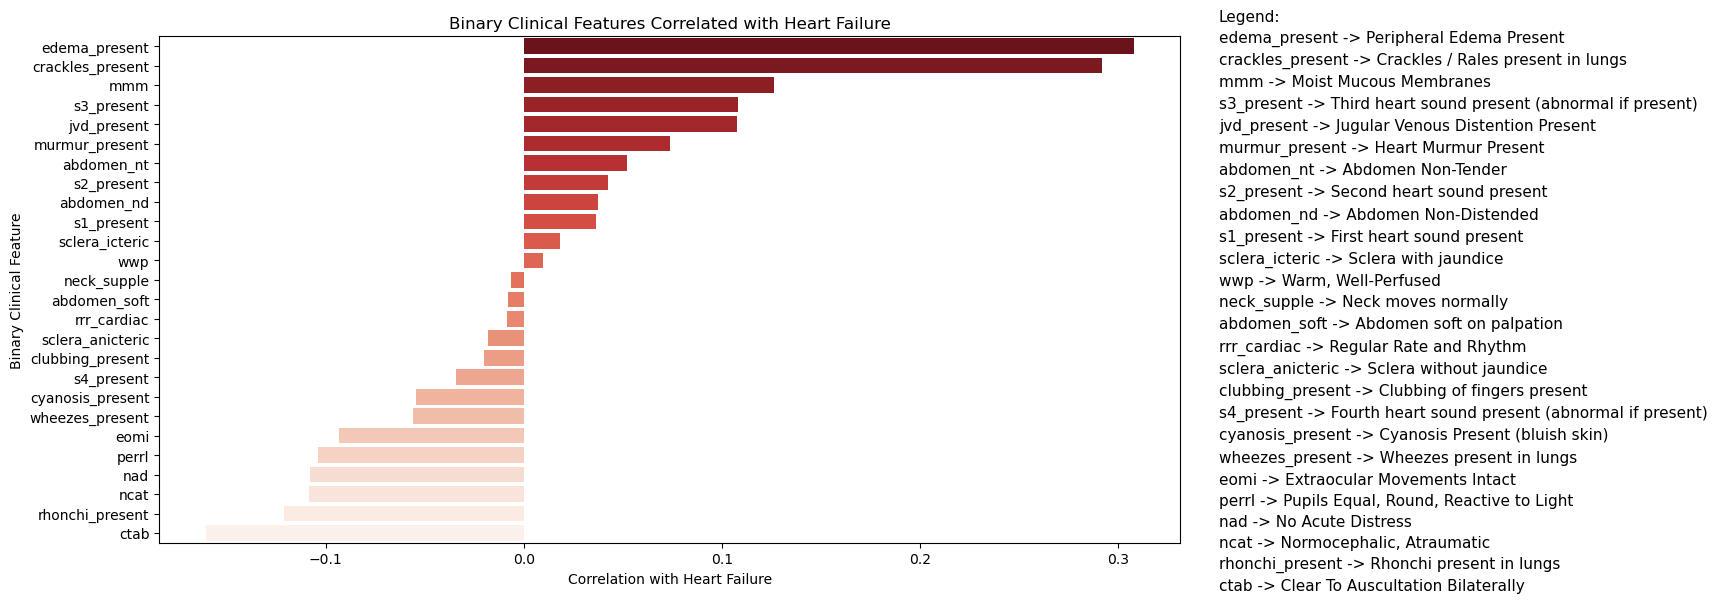

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# ================= Merge extracted features =================
df_merged_all_features = pd.concat([df, extracted_features], axis=1)

# ================= Create binary target =================
df_merged_all_features['heart_failure'] = (df_merged_all_features['icd_code'] == 'I50').astype(int)

# ================= Identify binary features =================
binary_features = extracted_features.columns[extracted_features.nunique().le(2)].tolist()
non_binary_like_vitals = ['temperature', 'bp_systolic', 'bp_diastolic', 
                          'heart_rate', 'respiratory_rate', 'oxygen_saturation']
binary_features = [col for col in binary_features if col not in non_binary_like_vitals]

# ================= Compute correlations =================
binary_df = df_merged_all_features[binary_features + ['heart_failure']]
binary_correlations = binary_df.corr()['heart_failure'].drop('heart_failure').sort_values(ascending=False)

# ================= Feature descriptions =================
feature_descriptions = {
    "oxygen_method": "Oxygen Delivery Method (RA, NRB, BiPAP, CPAP, etc.)",
    "perrl": "Pupils Equal, Round, Reactive to Light",
    "eomi": "Extraocular Movements Intact",
    "ncat": "Normocephalic, Atraumatic",
    "mmm": "Moist Mucous Membranes",
    "rrr_cardiac": "Regular Rate and Rhythm",
    "ctab": "Clear To Auscultation Bilaterally",
    "nad": "No Acute Distress",
    "wwp": "Warm, Well-Perfused",
    "abdomen_nt": "Abdomen Non-Tender",
    "abdomen_nd": "Abdomen Non-Distended",
    "oriented": "Alert and Oriented (x1, x2, x3)",
    "sclera_anicteric": "Sclera without jaundice",
    "sclera_icteric": "Sclera with jaundice",
    "neck_supple": "Neck moves normally",
    "jvd_present": "Jugular Venous Distention Present",
    "abdomen_soft": "Abdomen soft on palpation",
    "edema_present": "Peripheral Edema Present",
    "wheezes_present": "Wheezes present in lungs",
    "crackles_present": "Crackles / Rales present in lungs",
    "rhonchi_present": "Rhonchi present in lungs",
    "s1_present": "First heart sound present",
    "s2_present": "Second heart sound present",
    "s3_present": "Third heart sound present (abnormal if present)",
    "s4_present": "Fourth heart sound present (abnormal if present)",
    "murmur_present": "Heart Murmur Present",
    "clubbing_present": "Clubbing of fingers present",
    "cyanosis_present": "Cyanosis Present (bluish skin)",
    "edema_grade": "Grade of Edema (0=trace, 1+=mild, 2+=moderate, etc.)",
    "jvp_cm": "Jugular Venous Pressure in centimeters"
}

# Legend text sorted according to the correlation
sorted_features = binary_correlations.index.tolist()
feature_meaning_sorted = "Legend:\n"
feature_meaning_sorted += "\n".join([f"{f} -> {feature_descriptions.get(f, '')}" for f in sorted_features])

# ================= Plot =================
plt.figure(figsize=(12,6))
sns.barplot(x=binary_correlations.values, y=binary_correlations.index, palette="Reds_r")
plt.xlabel('Correlation with Heart Failure')
plt.ylabel('Binary Clinical Feature')
plt.title('Binary Clinical Features Correlated with Heart Failure')

# Legend outside, sorted according to the graph
plt.gcf().text(1.02, 0.5, feature_meaning_sorted, fontsize=11, va='center', linespacing=1.5)

plt.tight_layout()
plt.show()

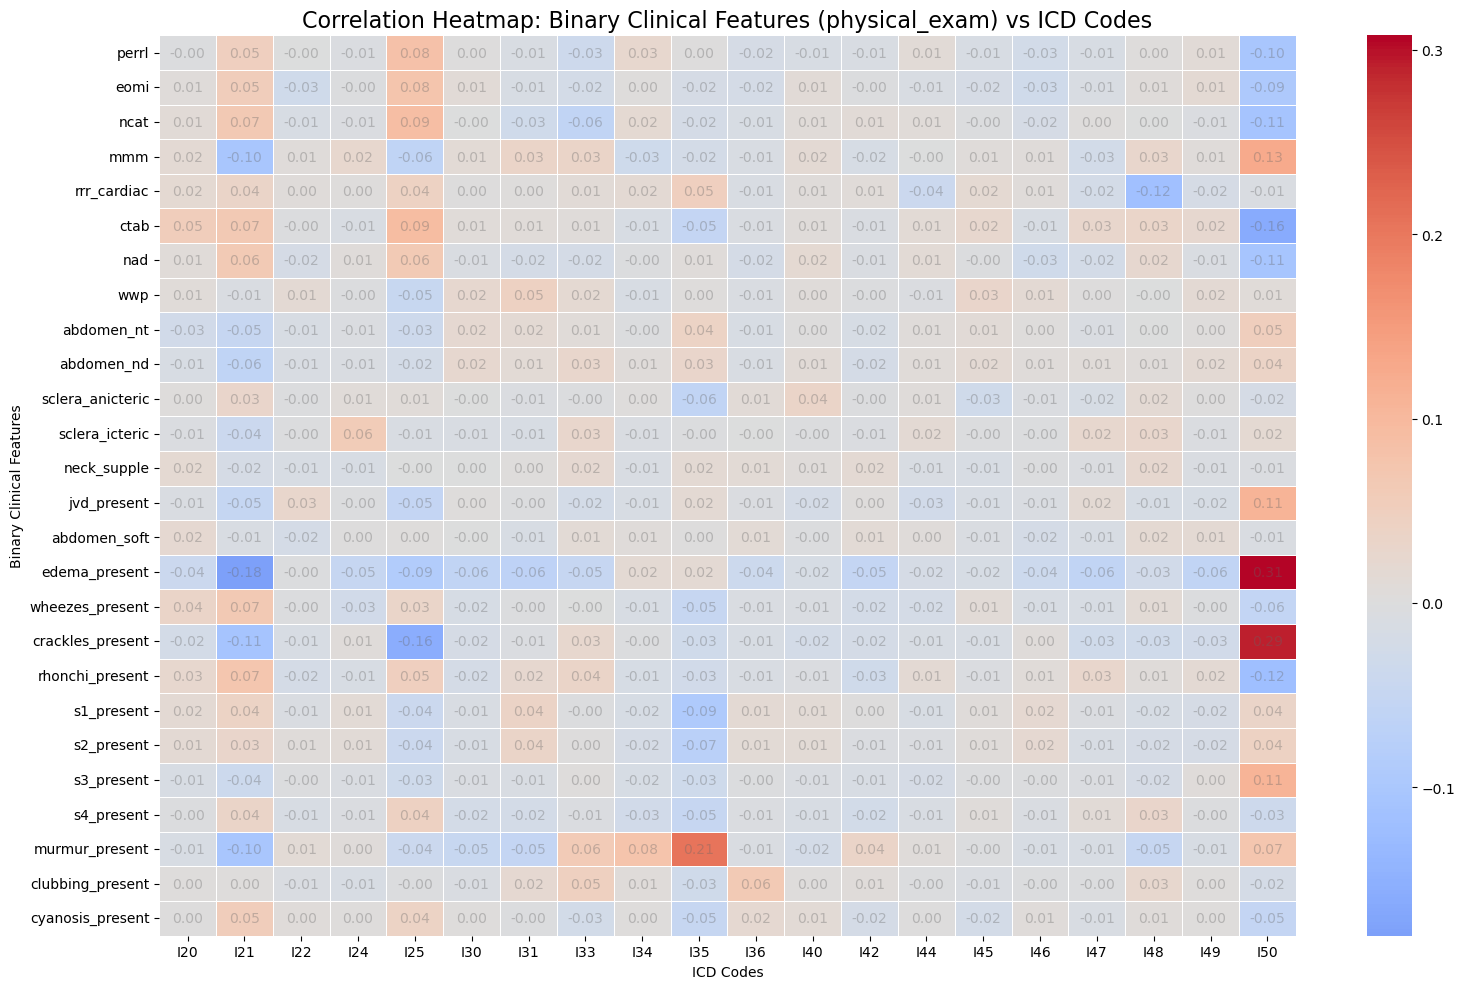

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# 1. One-hot encode ICD codes
# -------------------------------
icd_onehot = pd.get_dummies(df_merged_all_features['icd_code'])


icd_filter_list = [
    'I20', 'I21', 'I22', 'I24', 'I25', 'I30', 'I31', 'I33', 'I34', 'I35',
    'I36', 'I40', 'I42', 'I44', 'I45', 'I46', 'I47', 'I48', 'I49', 'I50'
]
icd_onehot = icd_onehot[icd_filter_list]

# -------------------------------
# 2. binary features
# -------------------------------
binary_df = df_merged_all_features[binary_features]

# -------------------------------
# 3. Combine features + ICD codes
# -------------------------------
corr_matrix = pd.concat([binary_df, icd_onehot], axis=1).corr()

# -----------------------------------------
# 4. Extract only correlations:
#    binary_features (rows) vs ICD codes (columns)
# -----------------------------------------
corr_subset = corr_matrix.loc[binary_features, icd_filter_list]

# -------------------------------
# 5. Plot Heatmap
# -------------------------------
plt.figure(figsize=(16, 10))
ax = sns.heatmap(
    corr_subset, 
    annot=True,
    fmt=".2f",
    
    cmap="coolwarm", 
    center=0,
    linewidths=0.5
)

for text in ax.texts:
    text.set_color("#666666")
    text.set_alpha(0.35)

plt.title("Correlation Heatmap: Binary Clinical Features (physical_exam) vs ICD Codes", fontsize=16)
plt.xlabel("ICD Codes")
plt.ylabel("Binary Clinical Features")
plt.tight_layout()
plt.show()

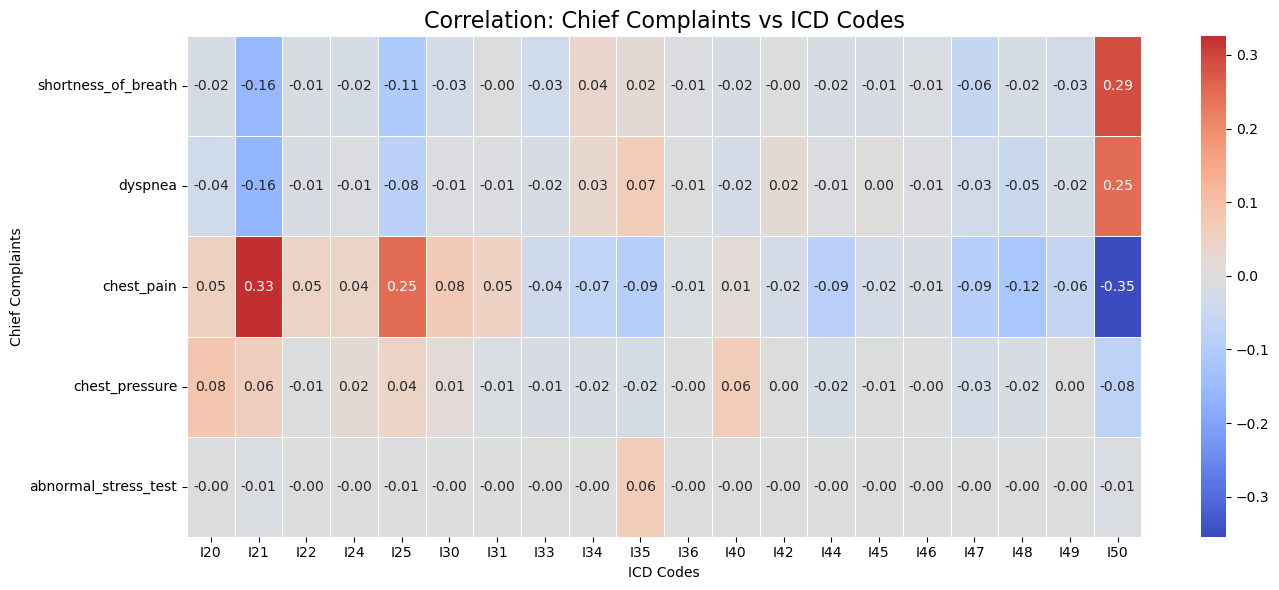

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 1. Normalize chief complaint text
# =========================
df_merged_all_features['chief_complaint'] = (
    df_merged_all_features['chief_complaint']
    .astype(str)
    .str.lower()
    .str.strip()
)

# =========================
# 2. Encode complaints (0/1)
# =========================
complaints_of_interest = {
    "shortness of breath": "shortness_of_breath",
    "dyspnea": "dyspnea",
    "chest pain": "chest_pain",
    "chest pressure": "chest_pressure",
    "abnormal stress test, new ai": "abnormal_stress_test"
}

# binary complaint features
for text, colname in complaints_of_interest.items():
    df_merged_all_features[colname] = df_merged_all_features['chief_complaint']\
        .str.contains(text, case=False, na=False).astype(int)

complaint_cols = list(complaints_of_interest.values())

# =========================
# 3. One-hot encode ICD codes
# =========================
icd_filter_list = [
    'I20','I21','I22','I24','I25','I30','I31','I33','I34','I35',
    'I36','I40','I42','I44','I45','I46','I47','I48','I49','I50'
]

icd_onehot = pd.get_dummies(df_merged_all_features['icd_code'])
icd_onehot = icd_onehot.reindex(columns=icd_filter_list, fill_value=0)

# =========================
# 4. Compute correlations between complaints × ICD codes
# =========================
corr_matrix = pd.concat([df_merged_all_features[complaint_cols], icd_onehot], axis=1).corr()
corr_subset = corr_matrix.loc[complaint_cols, icd_filter_list]

# =========================
# 5. Plot the heatmap
# =========================
plt.figure(figsize=(14, 6))
sns.heatmap(
    corr_subset,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Correlation: Chief Complaints vs ICD Codes", fontsize=16)
plt.xlabel("ICD Codes")
plt.ylabel("Chief Complaints")
plt.tight_layout()
plt.show()

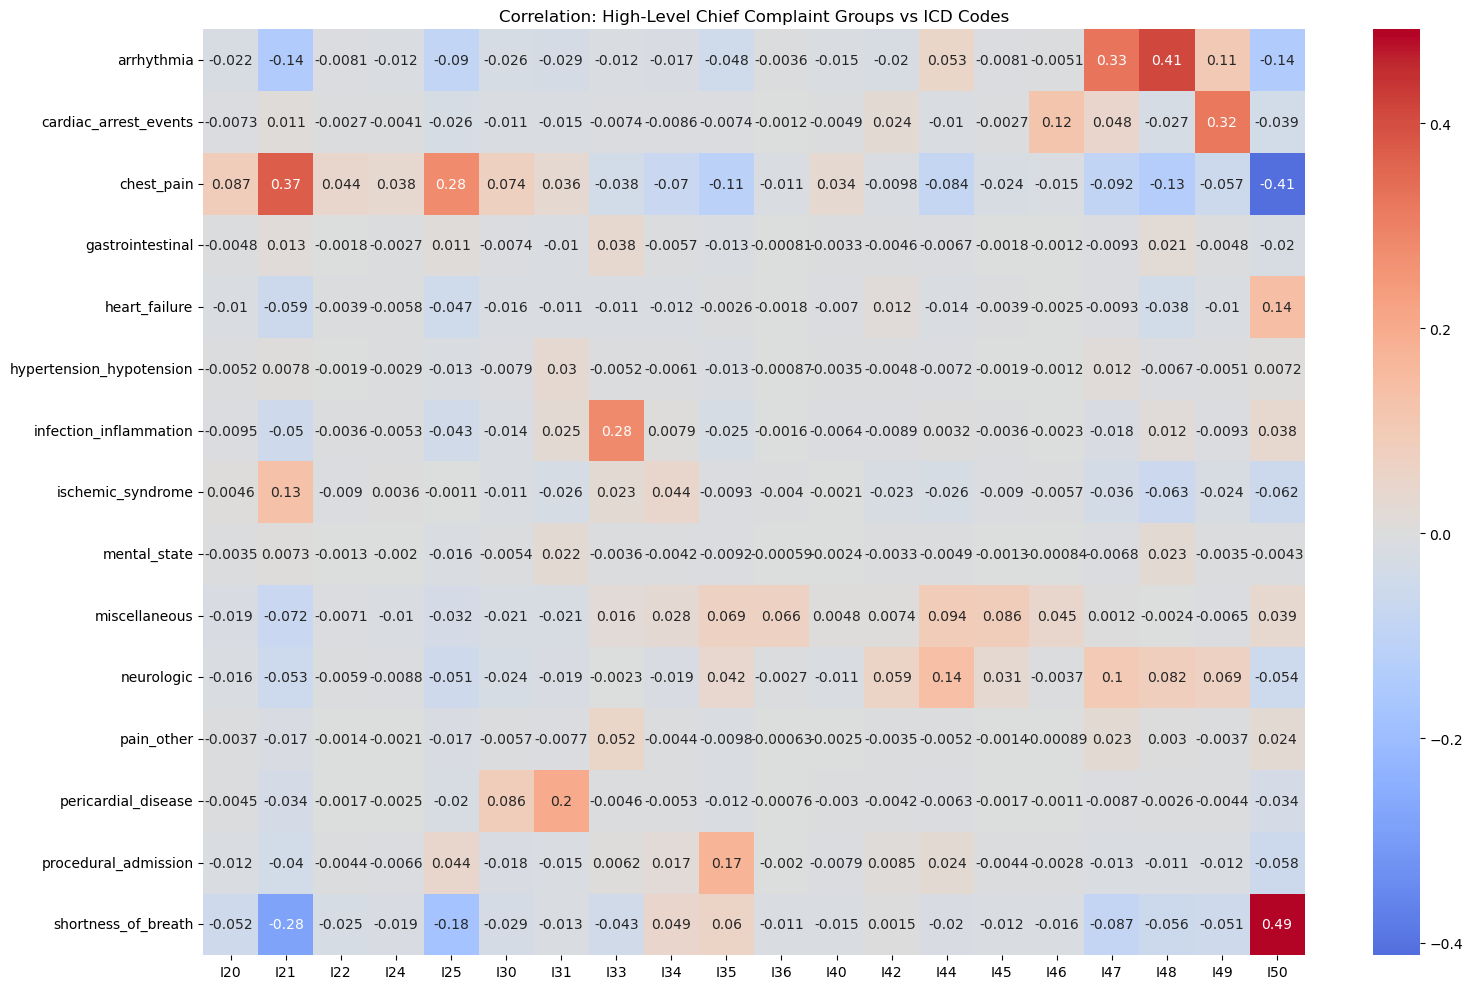

In [60]:
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================
# HIGH-LEVEL GROUPS
# ============================
complaint_groups = {
    "shortness_of_breath": [
        "shortness of breath", "sob", "dyspnea", "doe", "dsypnea", "dypnea", "dyspnoea",
        "respiratory distress", "acute respiratory distress",
        "hypoxia", "hypoxemia", "orthopnea", "pnd",
        "exercise intolerance", "decreased energy", "breath"
    ],

    "chest_pain": [
        "chest pain", "cp", "chest pressure", "chest heaviness", "chest discomfort",
        "chest tightness", "burning", "pleuritic", "substernal", "jaw pain",
        "arm pain", "shoulder pain", "back pain", "r cva pain",
        "epigastric pain", "epigastric", "heart burn", "throat pain"
    ],

    "arrhythmia": [
        "atrial fibrillation", "afib", "a fib", "atrial flutter", "aflutter",
        "svt", "vtach", "ventricular tachycardia", "vt", "vfib", "v tach",
        "rvr", "flutter", "tachycardia", "bradycardia", "torsades",
        "wide complex", "irregular heart", "pvc", "pvc's",
        "icd firing", "icd beeping", "icd shocks", "palpitation",
        "palpitations", "rapid heart rate", "pounding heartbeat"
    ],

    "ischemic_syndrome": [
        "nstemi", "stemi", "myocardial infarction", "mi", "inferior stemi",
        "ischemia", "infarction", "acs", "angina", "unstable angina",
        "st elevation", "abnormal ekg", "abnormal ecg",
        "perfusion defect", "positive stress test", "abnormal stress test",
        "t-wave inversion"
    ],

    "heart_failure": [
        "heart failure", "hf", "chf", "acute on chronic", "exacerbation",
        "volume overload", "weight gain", "fluid overload",
        "pnd", "orthopnea", "congestive", "cardiogenic shock"
    ],

    "cardiac_arrest_events": [
        "cardiac arrest", "vf arrest", "v-fib arrest", "pea arrest",
        "post cardiac arrest", "vfib arrest", "vt storm"
    ],

    "procedural_admission": [
        "transfer", "for cath", "catheterization", "pci", "tavr", "mitraclip",
        "hydration", "evaluation", "scheduled", "elective", "work-up",
        "device", "pvi", "ablation", "pacemaker", "replacement"
    ],

    "pericardial_disease": [
        "tamponade", "pericardial effusion", "pericarditis"
    ],

    "infection_inflammation": [
        "fever", "bacteremia", "infection", "endocarditis",
        "uti", "viral", "sepsis", "cough", "productive cough",
        "hemoptysis", "pneumonia"
    ],

    "gastrointestinal": [
        "nausea", "vomiting", "diarrhea", "abdominal", "abd pain",
        "ruq pain", "boating"
    ],

    "neurologic": [
        "syncope", "presyncope", "faint", "lightheaded", "weakness",
        "unresponsiveness", "altered mental status", "ams", "confusion",
        "delirium", "somnolence", "dizziness", "tingling"
    ],

    "hypertension_hypotension": [
        "hypertension", "hypotension", "orthostatic"
    ],

    "mental_state": [
        "malaise", "not feeling well", "feeling lousy", "panic attack",
        "feeling funny"
    ],

    "pain_other": [
        "leg pain", "flank pain", "rib pain", "toe pain",
        "calf pain", "lower extremity pain", "knee pain"
    ]
}

# ==============================
# Mapping function
# ==============================
def map_complaint_v2(text):
    if pd.isna(text):
        return "miscellaneous"
    t = text.lower()
    for group, keywords in complaint_groups.items():
        for kw in keywords:
            if kw in t:
                return group
    return "miscellaneous"

# Apply mapping
df_merged_all_features["complaint_group"] = (
    df_merged_all_features["chief_complaint"].astype(str).apply(map_complaint_v2)
)

# ==============================
# ICD correlation heatmap
# ==============================
icd_list = [
    'I20','I21','I22','I24','I25','I30','I31','I33','I34','I35',
    'I36','I40','I42','I44','I45','I46','I47','I48','I49','I50'
]

icd_onehot = pd.get_dummies(df_merged_all_features['icd_code'])
icd_onehot = icd_onehot.reindex(columns=icd_list, fill_value=0)

corr_matrix = pd.concat(
    [pd.get_dummies(df_merged_all_features["complaint_group"]), icd_onehot],
    axis=1
).corr()

corr_subset = corr_matrix.loc[
    pd.get_dummies(df_merged_all_features["complaint_group"]).columns,
    icd_list
]

plt.figure(figsize=(16,10))
sns.heatmap(corr_subset, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation: High-Level Chief Complaint Groups vs ICD Codes")
plt.tight_layout()
plt.show()


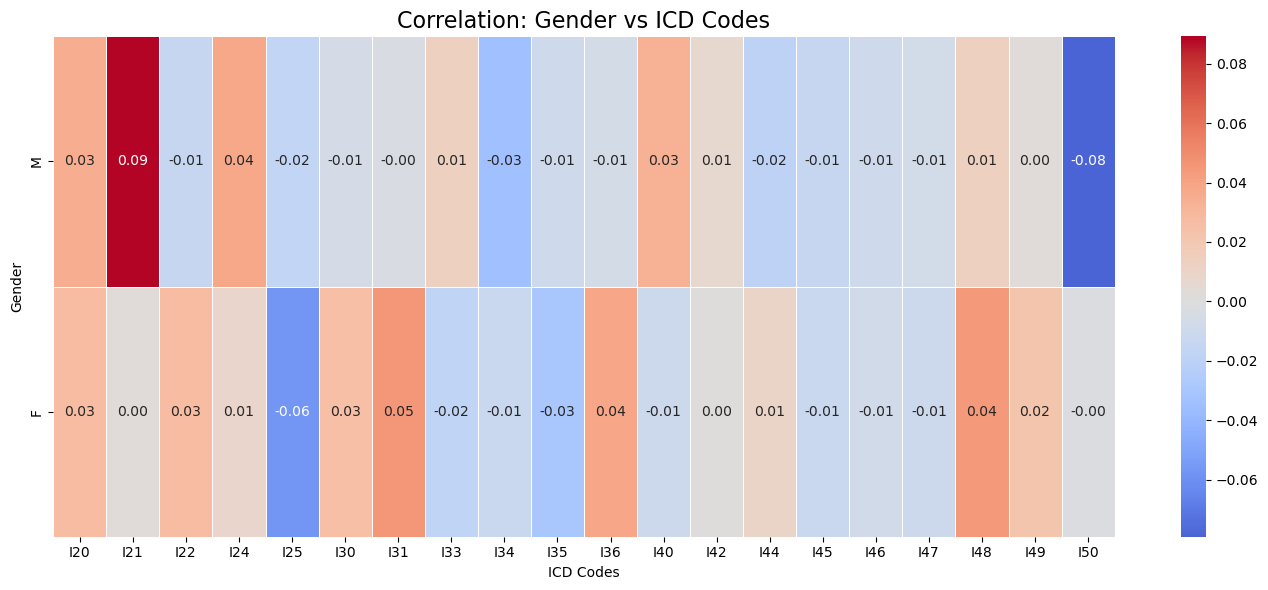

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 1. Direct binary encoding of gender
# =========================
df_merged_all_features['M'] = (df_merged_all_features['gender'].str.upper() == 'M').astype(int)
df_merged_all_features['F'] = (df_merged_all_features['gender'].str.upper() == 'F').astype(int)
complaint_cols = ['M', 'F']

# =========================
# 2. One-hot encode ICD codes
# =========================
icd_filter_list = [
    'I20','I21','I22','I24','I25','I30','I31','I33','I34','I35',
    'I36','I40','I42','I44','I45','I46','I47','I48','I49','I50'
]

icd_onehot = pd.get_dummies(df_merged_all_features['icd_code'])
icd_onehot = icd_onehot.reindex(columns=icd_filter_list, fill_value=0)

# =========================
# 3. Compute correlations (Gender × ICD)
# =========================
corr_matrix = pd.concat([df_merged_all_features[complaint_cols], icd_onehot], axis=1).corr()
corr_subset = corr_matrix.loc[complaint_cols, icd_filter_list]

# =========================
# 4. Plot the heatmap
# =========================
plt.figure(figsize=(14, 6))
sns.heatmap(
    corr_subset,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Correlation: Gender vs ICD Codes", fontsize=16)
plt.xlabel("ICD Codes")
plt.ylabel("Gender")
plt.tight_layout()
plt.show()